In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score)
from xgboost import XGBClassifier
import shap
import joblib
import json



In [ ]:
from pathlib import Path

# Root paths
project_path    = Path("../..").resolve()          # Project/
data_path       = project_path / "data"
processed_path  = data_path / "processed"          # colleague's files

# output paths
xai_path        = project_path / "XAI_2026"
models_path     = xai_path / "models"
artifacts_path  = xai_path / "artifacts"
outputs_path    = xai_path / "outputs"

# Create folders if they don't exist
models_path.mkdir(parents=True, exist_ok=True)
artifacts_path.mkdir(parents=True, exist_ok=True)
outputs_path.mkdir(parents=True, exist_ok=True)

print("Project structure ready ")
print(f"  Reading data from : {processed_path}")
print(f"  Saving models to  : {models_path}")
print(f"  Saving arrays to  : {artifacts_path}")
print(f"  Saving plots to   : {outputs_path}")

In [18]:
# Load data
df = pd.read_csv("C:\\Users\\shahe\\4XAI\\Project\\data\\processed\\ravdess_mfcc_features_v2.csv")

In [19]:
df

,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,mfcc_mean_7,mfcc_mean_8,mfcc_mean_9,mfcc_mean_10,...,mfcc_delta_std_34,mfcc_delta_std_35,mfcc_delta_std_36,mfcc_delta_std_37,mfcc_delta_std_38,mfcc_delta_std_39,mfcc_delta_std_40,Emotion,Emotion_ID,Path
0,-398.04220,75.356050,3.555152,13.388279,6.033112,15.046699,-3.274679,3.410381,-3.609158,-1.716895,...,0.666572,0.683853,0.649953,0.690861,0.616112,0.641250,0.650382,neutral,5,C:\Users\shahe\4XAI\Project\data\raw\Actor_01\...
1,-404.41440,77.657196,1.182115,14.425774,8.691035,15.811256,-4.619638,4.848064,-4.008130,-4.158945,...,0.558050,0.517243,0.643897,0.560654,0.735399,0.663243,0.650409,neutral,5,C:\Users\shahe\4XAI\Project\data\raw\Actor_01\...
2,-423.03020,75.066860,3.681056,12.329444,6.456292,11.320029,-3.664177,4.332827,-5.347966,-3.426528,...,0.715581,0.730944,0.651703,0.507533,0.522464,0.576221,0.716872,neutral,5,C:\Users\shahe\4XAI\Project\data\raw\Actor_01\...
3,-431.44470,70.960460,5.918694,13.914023,6.412232,13.075801,-2.052994,5.827670,-5.217687,-3.630437,...,0.679620,0.560773,0.626818,0.622375,0.622986,0.500272,0.799045,neutral,5,C:\Users\shahe\4XAI\Project\data\raw\Actor_01\...
4,-374.96695,88.756744,6.575492,16.645142,7.118174,16.783058,-3.964944,5.049708,-6.502435,-1.174364,...,0.624812,0.677422,0.675885,0.721127,0.824473,0.579583,0.562428,calm,1,C:\Users\shahe\4XAI\Project\data\raw\Actor_01\...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-385.39197,52.095585,-22.968992,4.256605,-12.684442,-4.531819,-16.086650,-5.415159,-17.741135,-9.599253,...,1.285289,1.215589,1.262447,1.441106,1.409283,1.500882,1.266859,surprise,7,C:\Users\shahe\4XAI\Project\data\raw\Actor_24\...
1436,-369.15814,74.104320,-19.512238,3.407336,-18.050701,-5.426367,-22.706207,-6.697923,-13.299150,-11.602337,...,1.587545,1.677188,1.400912,1.257759,1.049124,1.029541,0.989744,surprise,7,C:\Users\shahe\4XAI\Project\data\raw\Actor_24\...
1437,-339.16750,70.145325,-28.976427,6.397467,-16.471600,-3.564403,-27.153255,-8.337615,-14.180528,-11.658910,...,1.431605,1.192082,1.419744,1.308439,1.488462,1.324050,1.054987,surprise,7,C:\Users\shahe\4XAI\Project\data\raw\Actor_24\...
1438,-345.55200,52.704910,-18.165882,15.100112,-14.326173,1.605802,-16.545298,0.559315,-16.987654,-3.354616,...,1.185229,1.364777,1.054514,1.022725,1.226704,0.876141,0.904909,surprise,7,C:\Users\shahe\4XAI\Project\data\raw\Actor_24\...


In [21]:
feature_cols = [c for c in df.columns
                if c.startswith("mfcc_")]                  # grabs all 160
X = df[feature_cols].values
print("Feature matrix shape:", X.shape)   


Feature matrix shape: (1440, 160)


In [22]:
y        = df["Emotion_ID"].values
y_text   = df["Emotion"].values
classes  = ['angry','calm','disgust','fear','happy','neutral','sad','surprise']

print("Feature matrix shape:", X.shape)   # (1440, 40)
print("Labels shape:", y.shape)           # (1440,)

Feature matrix shape: (1440, 160)
Labels shape: (1440,)


In [23]:
print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)
print("Classes:", sorted(classes))

Feature matrix shape: (1440, 160)
Labels shape: (1440,)
Classes: ['angry', 'calm', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


C:\Users\shahe\AppData\Local\Temp\ipykernel_49220\923011482.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="viridis")


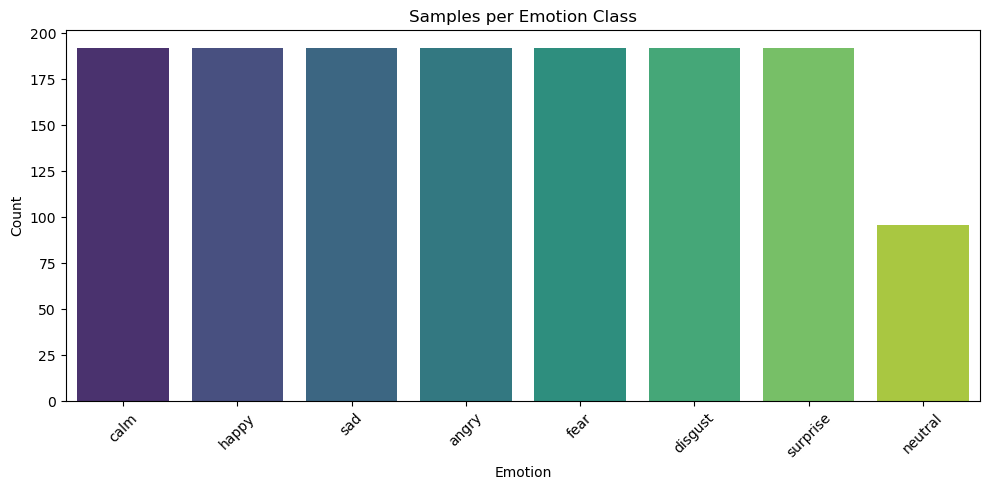

In [24]:
# Always check balance BEFORE training
emotion_counts = pd.Series(y_text).value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="viridis")
plt.title("Samples per Emotion Class")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Expected output:
# happy, sad, angry, etc. → 192 samples each
# neutral                 → 96 samples (imbalanced!) ← important to note

# Split & Scale

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train size:", X_train_scaled.shape)   # (1152, 40)
print("Test size:",  X_test_scaled.shape)    # (288, 40)

Train size: (1152, 160)
Test size: (288, 160)


# Cross Validation BEFORE Final Training

In [28]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV      
from scipy.stats import randint, uniform
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ─────────────────────────────────────────
# RANDOM FOREST TUNING
# ─────────────────────────────────────────
rf_param_grid = {
    'n_estimators':      randint(100, 500),      # try 100 to 500 trees
    'max_depth':         [None, 5, 10, 15, 20],  # how deep each tree grows
    'min_samples_split': randint(2, 20),          # min samples to split a node
    'min_samples_leaf':  randint(1, 10),          # min samples at leaf node
    'max_features':      ['sqrt', 'log2', 0.5]   # features considered per split
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=30,               # try 30 random combinations
    cv=cv,                   # 5-fold stratified CV
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,               # parallel processing
    verbose=1                # shows progress
)
rf_search.fit(X_train_scaled, y_train)

print("="*50)
print("RANDOM FOREST — Best Parameters:")
print(rf_search.best_params_)
print(f"Best CV F1: {rf_search.best_score_:.3f}")

# ─────────────────────────────────────────
# XGBOOST TUNING
# ─────────────────────────────────────────
xgb_param_grid = {
    'n_estimators':     randint(100, 500),       # number of trees
    'learning_rate':    uniform(0.01, 0.3),      # step size (0.01 to 0.31)
    'max_depth':        randint(3, 10),           # tree depth
    'subsample':        uniform(0.6, 0.4),        # % samples per tree (0.6-1.0)
    'colsample_bytree': uniform(0.6, 0.4),        # % features per tree (0.6-1.0)
    'min_child_weight': randint(1, 10),           # minimum samples in leaf
    'gamma':            uniform(0, 0.5)           # minimum loss reduction to split
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_distributions=xgb_param_grid,
    n_iter=30,               # try 30 random combinations
    cv=cv,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train_scaled, y_train)

print("="*50)
print("XGBOOST — Best Parameters:")
print(xgb_search.best_params_)
print(f"Best CV F1: {xgb_search.best_score_:.3f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
RANDOM FOREST — Best Parameters:
{'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 108}
Best CV F1: 0.560
Fitting 5 folds for each of 30 candidates, totalling 150 fits
XGBOOST — Best Parameters:
{'colsample_bytree': 0.8497416192535173, 'gamma': 0.147816842918857, 'learning_rate': 0.041648277949081186, 'max_depth': 6, 'min_child_weight': 4, 'n_estimators': 385, 'subsample': 0.9533121035675474}
Best CV F1: 0.628


In [29]:
print("\n" + "="*50)
print("TUNING SUMMARY")
print("="*50)
print(f"Random Forest best CV F1 : {rf_search.best_score_:.3f}")
print(f"XGBoost       best CV F1 : {xgb_search.best_score_:.3f}")

# Pick the winner automatically
if xgb_search.best_score_ >= rf_search.best_score_:
    best_params  = xgb_search.best_params_
    best_name    = "XGBoost"
    print(f"\nWinner: XGBoost ")
else:
    best_params  = rf_search.best_params_
    best_name    = "Random Forest "
    print(f"\nWinner: Random Forest ")

print(f"Best Parameters: {best_params}")


TUNING SUMMARY
Random Forest best CV F1 : 0.560
XGBoost       best CV F1 : 0.628

Winner: XGBoost 
Best Parameters: {'colsample_bytree': 0.8497416192535173, 'gamma': 0.147816842918857, 'learning_rate': 0.041648277949081186, 'max_depth': 6, 'min_child_weight': 4, 'n_estimators': 385, 'subsample': 0.9533121035675474}


# 5 — Train Final Models

In [31]:
# Automatically uses whatever won above
if best_name == "XGBoost":
    final_model = XGBClassifier(
        **xgb_search.best_params_,     # unpack best params directly
        random_state=42,
        eval_metric='mlogloss'
    )
else:
    final_model = RandomForestClassifier(
        **rf_search.best_params_,
        random_state=42,
        n_jobs=-1
    )

# NOW train permanently on full training set
final_model.fit(X_train_scaled, y_train)
print(f"Final {best_name} model trained ")

Final XGBoost model trained 


# 6 — Comprehensive Evaluation

In [32]:
y_pred = final_model.predict(X_test_scaled)

print("="*50)
print(f"FINAL {best_name} — Test Set Results")
print("="*50)
print(f"Accuracy:     {accuracy_score(y_test, y_pred):.3f}")
print(f"Weighted F1:  {f1_score(y_test, y_pred, average='weighted'):.3f}")
print(f"Macro F1:     {f1_score(y_test, y_pred, average='macro'):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=classes))

FINAL XGBoost — Test Set Results
Accuracy:     0.632
Weighted F1:  0.630
Macro F1:     0.625

              precision    recall  f1-score   support

       angry       0.55      0.76      0.64        38
        calm       0.61      0.61      0.61        38
     disgust       0.68      0.66      0.67        38
        fear       0.66      0.74      0.70        39
       happy       0.64      0.46      0.54        39
     neutral       0.59      0.53      0.56        19
         sad       0.61      0.61      0.61        38
    surprise       0.76      0.64      0.69        39

    accuracy                           0.63       288
   macro avg       0.64      0.63      0.63       288
weighted avg       0.64      0.63      0.63       288



##  Confusion Matrix

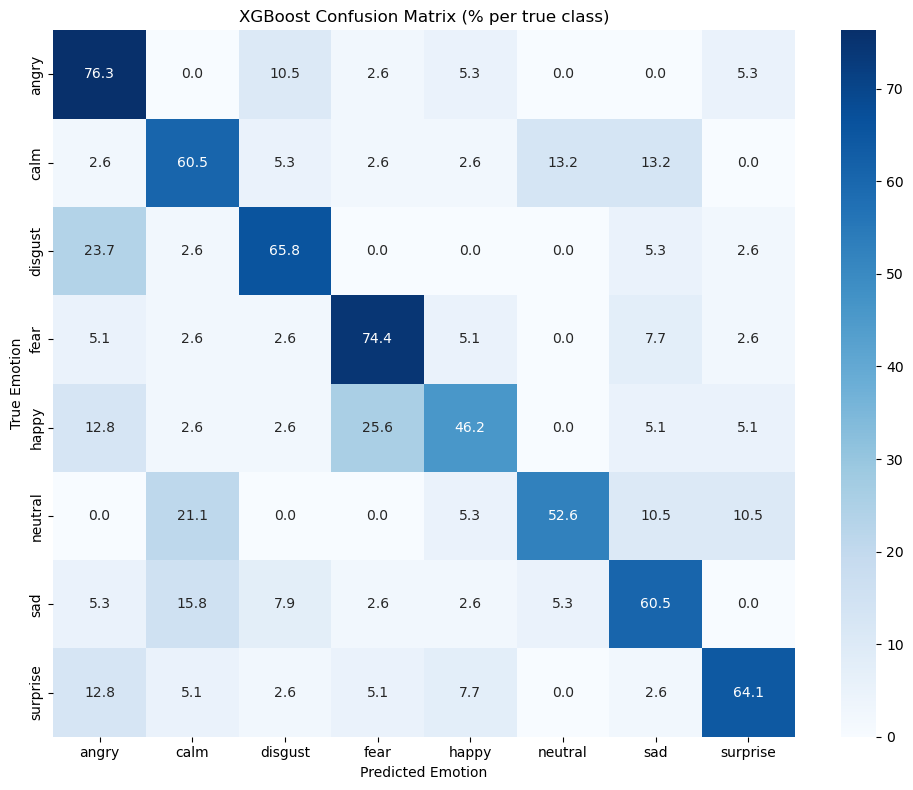

In [39]:
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(cm_pct, annot=True, fmt='.1f',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.title(f'{best_name} Confusion Matrix (% per true class)')
plt.ylabel('True Emotion')
plt.xlabel('Predicted Emotion')
plt.tight_layout()
plt.savefig(outputs_path / "confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

**Confusion Matrix Analysis — Emotion by Emotion**

## Per Emotion F1 Bar Chart

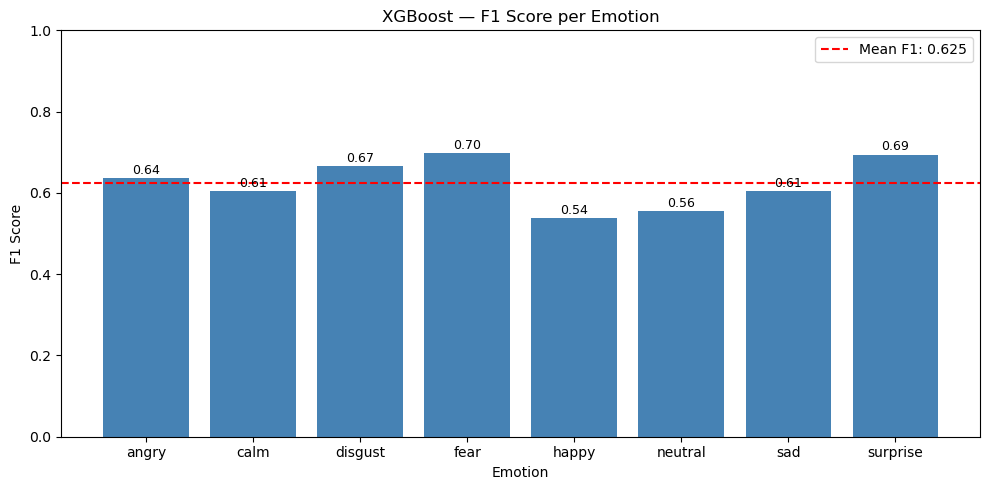

In [40]:
per_emotion_f1 = f1_score(y_test, y_pred, average=None)

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, per_emotion_f1, color='steelblue')
plt.title(f'{best_name} — F1 Score per Emotion')
plt.xlabel('Emotion')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.axhline(y=per_emotion_f1.mean(), color='red',
            linestyle='--', label=f'Mean F1: {per_emotion_f1.mean():.3f}')
plt.legend()

# Add value labels on bars
for bar, val in zip(bars, per_emotion_f1):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(outputs_path / "per_emotion_f1.png", dpi=150, bbox_inches='tight')
plt.show()

### Verdict — Ready for SHAP 
Your model is:
- Consistent (test ≈ CV score)
- Above random chance (63% vs 12.5% baseline)
- Has clear confusion patterns worth explainin
- Not overfitting
- Has enough errors to make SHAP interesting

Most importantly for XAI:
  The confusions are MEANINGFUL
  (high arousal vs high arousal, quiet vs quiet)
  SHAP should confirm these acoustic relationships
  and give you quantified evidence 

## saving modeland scaler

In [41]:
# Models
joblib.dump(final_model, models_path / "xgb_final_model.pkl")
joblib.dump(scaler,      models_path / "scaler.pkl")
best_params_dict = {k: float(v) if hasattr(v, 'item') 
                    else v for k, v in xgb_search.best_params_.items()}
with open(models_path / "xgb_best_params.json", "w") as f:
    json.dump(best_params_dict, f, indent=4)

# Arrays
np.save(artifacts_path / "X_test_scaled.npy",  X_test_scaled)
np.save(artifacts_path / "X_train_scaled.npy", X_train_scaled)
np.save(artifacts_path / "y_test.npy",          y_test)
np.save(artifacts_path / "y_train.npy",         y_train)
np.save(artifacts_path / "y_pred.npy",          y_pred)



print("All saved to correct locations ")

All saved to correct locations 


In [42]:
# Loading the saved objects
final_model    = joblib.load(models_path    / "xgb_final_model.pkl")
scaler         = joblib.load(models_path    / "scaler.pkl")
X_test_scaled  = np.load(artifacts_path    / "X_test_scaled.npy")
y_test         = np.load(artifacts_path    / "y_test.npy")

# SHAP Analysis

### Setup SHAP

In [43]:
import shap

# Feature names for all 160 features
feature_names = (
    [f"mfcc_mean_{i+1}"       for i in range(40)] +
    [f"mfcc_std_{i+1}"        for i in range(40)] +
    [f"mfcc_delta_mean_{i+1}" for i in range(40)] +
    [f"mfcc_delta_std_{i+1}"  for i in range(40)]
)

# Create explainer using training data as background
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values shape:", shap_values.shape)

# Expected: (288, 160, 8)
#             ↑    ↑    ↑
#           test  160   8
#          samples feat emotions

SHAP values shape: (288, 160, 8)


In [45]:
# Add this right after you define feature_names in Block 1
feature_names = np.array(feature_names)   # ← convert list to numpy array

print(type(feature_names))   # → <class 'numpy.ndarray'> 
print(feature_names.shape)   # → (160,) 

<class 'numpy.ndarray'>
(160,)


### 2 — Global Feature Importance (Overall)

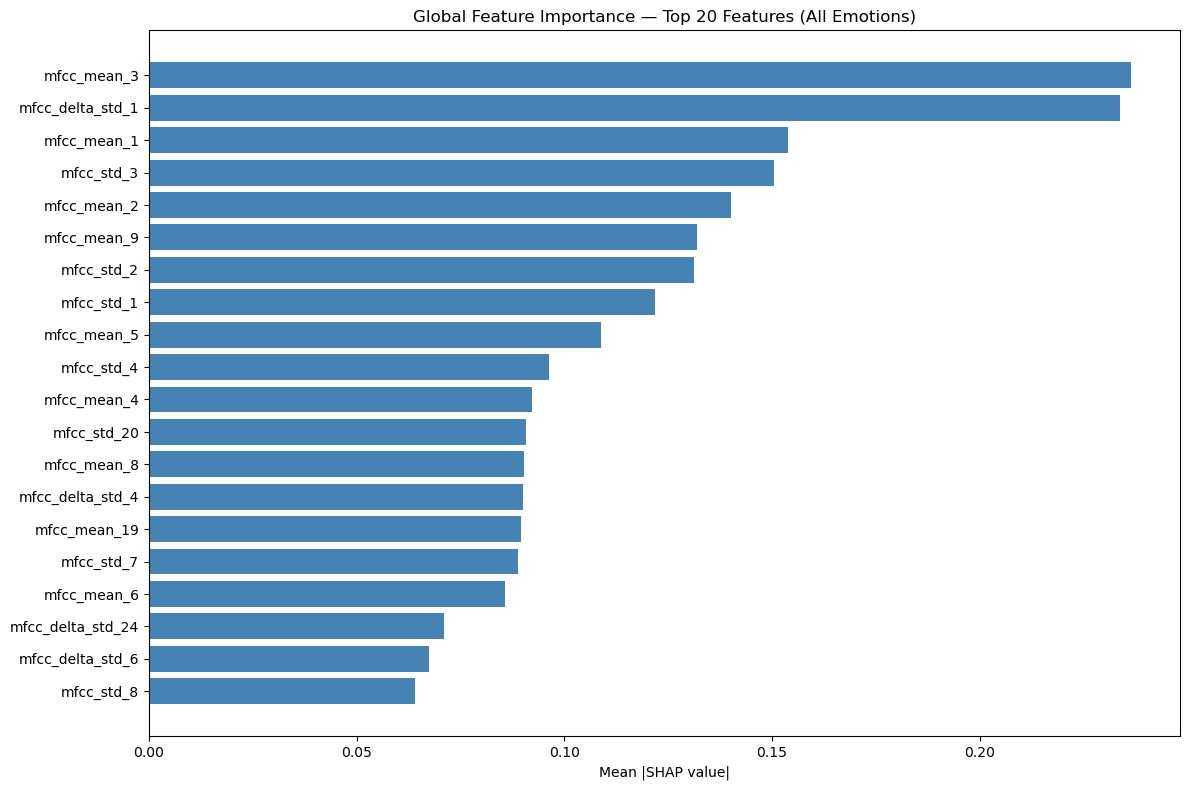

In [51]:
# Compute mean absolute SHAP across all emotions manually
mean_shap_all = np.abs(shap_values).mean(axis=(0, 2))  # (160,)

# Sort top 20
top20_idx   = np.argsort(mean_shap_all)[::-1][:20]
top20_vals  = mean_shap_all[top20_idx]
top20_names = feature_names[top20_idx]

plt.figure(figsize=(12, 8))
plt.barh(range(20), top20_vals[::-1], color='steelblue')
plt.yticks(range(20), top20_names[::-1])
plt.xlabel("Mean |SHAP value|")
plt.title("Global Feature Importance — Top 20 Features (All Emotions)")
plt.tight_layout()
plt.savefig(outputs_path / "shap_global_importance.png", dpi=150, bbox_inches='tight')
plt.show()

### 3 — Dot Summary Plot (Direction of Impact)

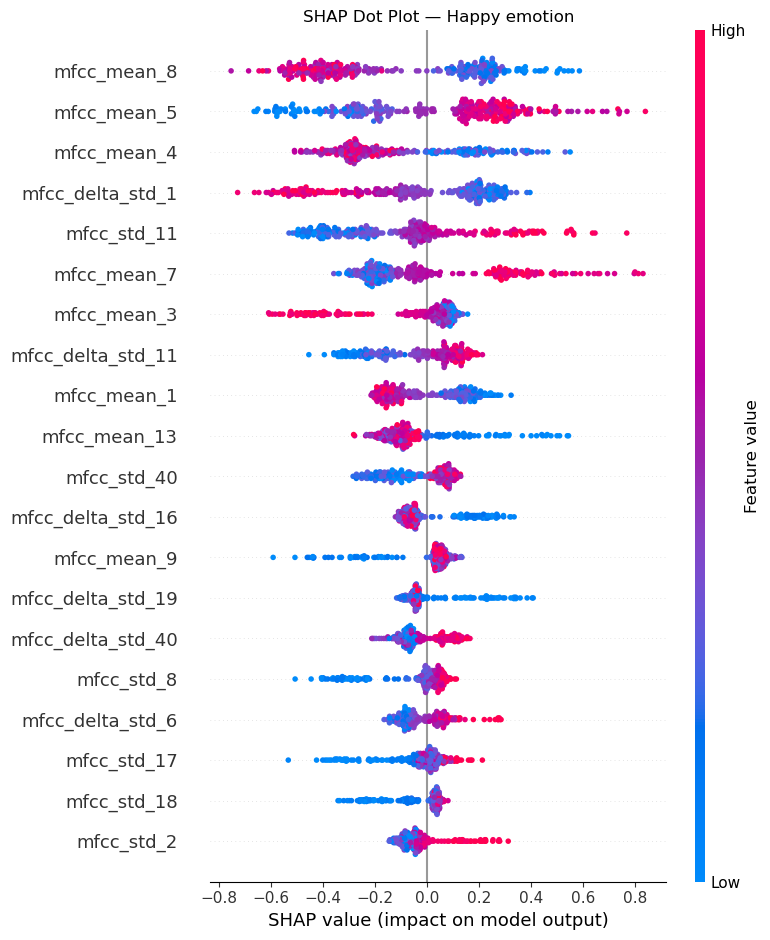

In [47]:
# Pick the hardest emotion pair from confusion matrix
# happy was worst (F1=0.54) → investigate first
emotion_idx = classes.index('happy')   # → 4

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values[:, :, emotion_idx],
    X_test_scaled,
    feature_names=feature_names,
    show=False
)
plt.title(f"SHAP Dot Plot — Happy emotion")
plt.tight_layout()
plt.savefig(outputs_path / "shap_dot_happy.png", dpi=150, bbox_inches='tight')
plt.show()

### 4 — Per Emotion SHAP Comparison

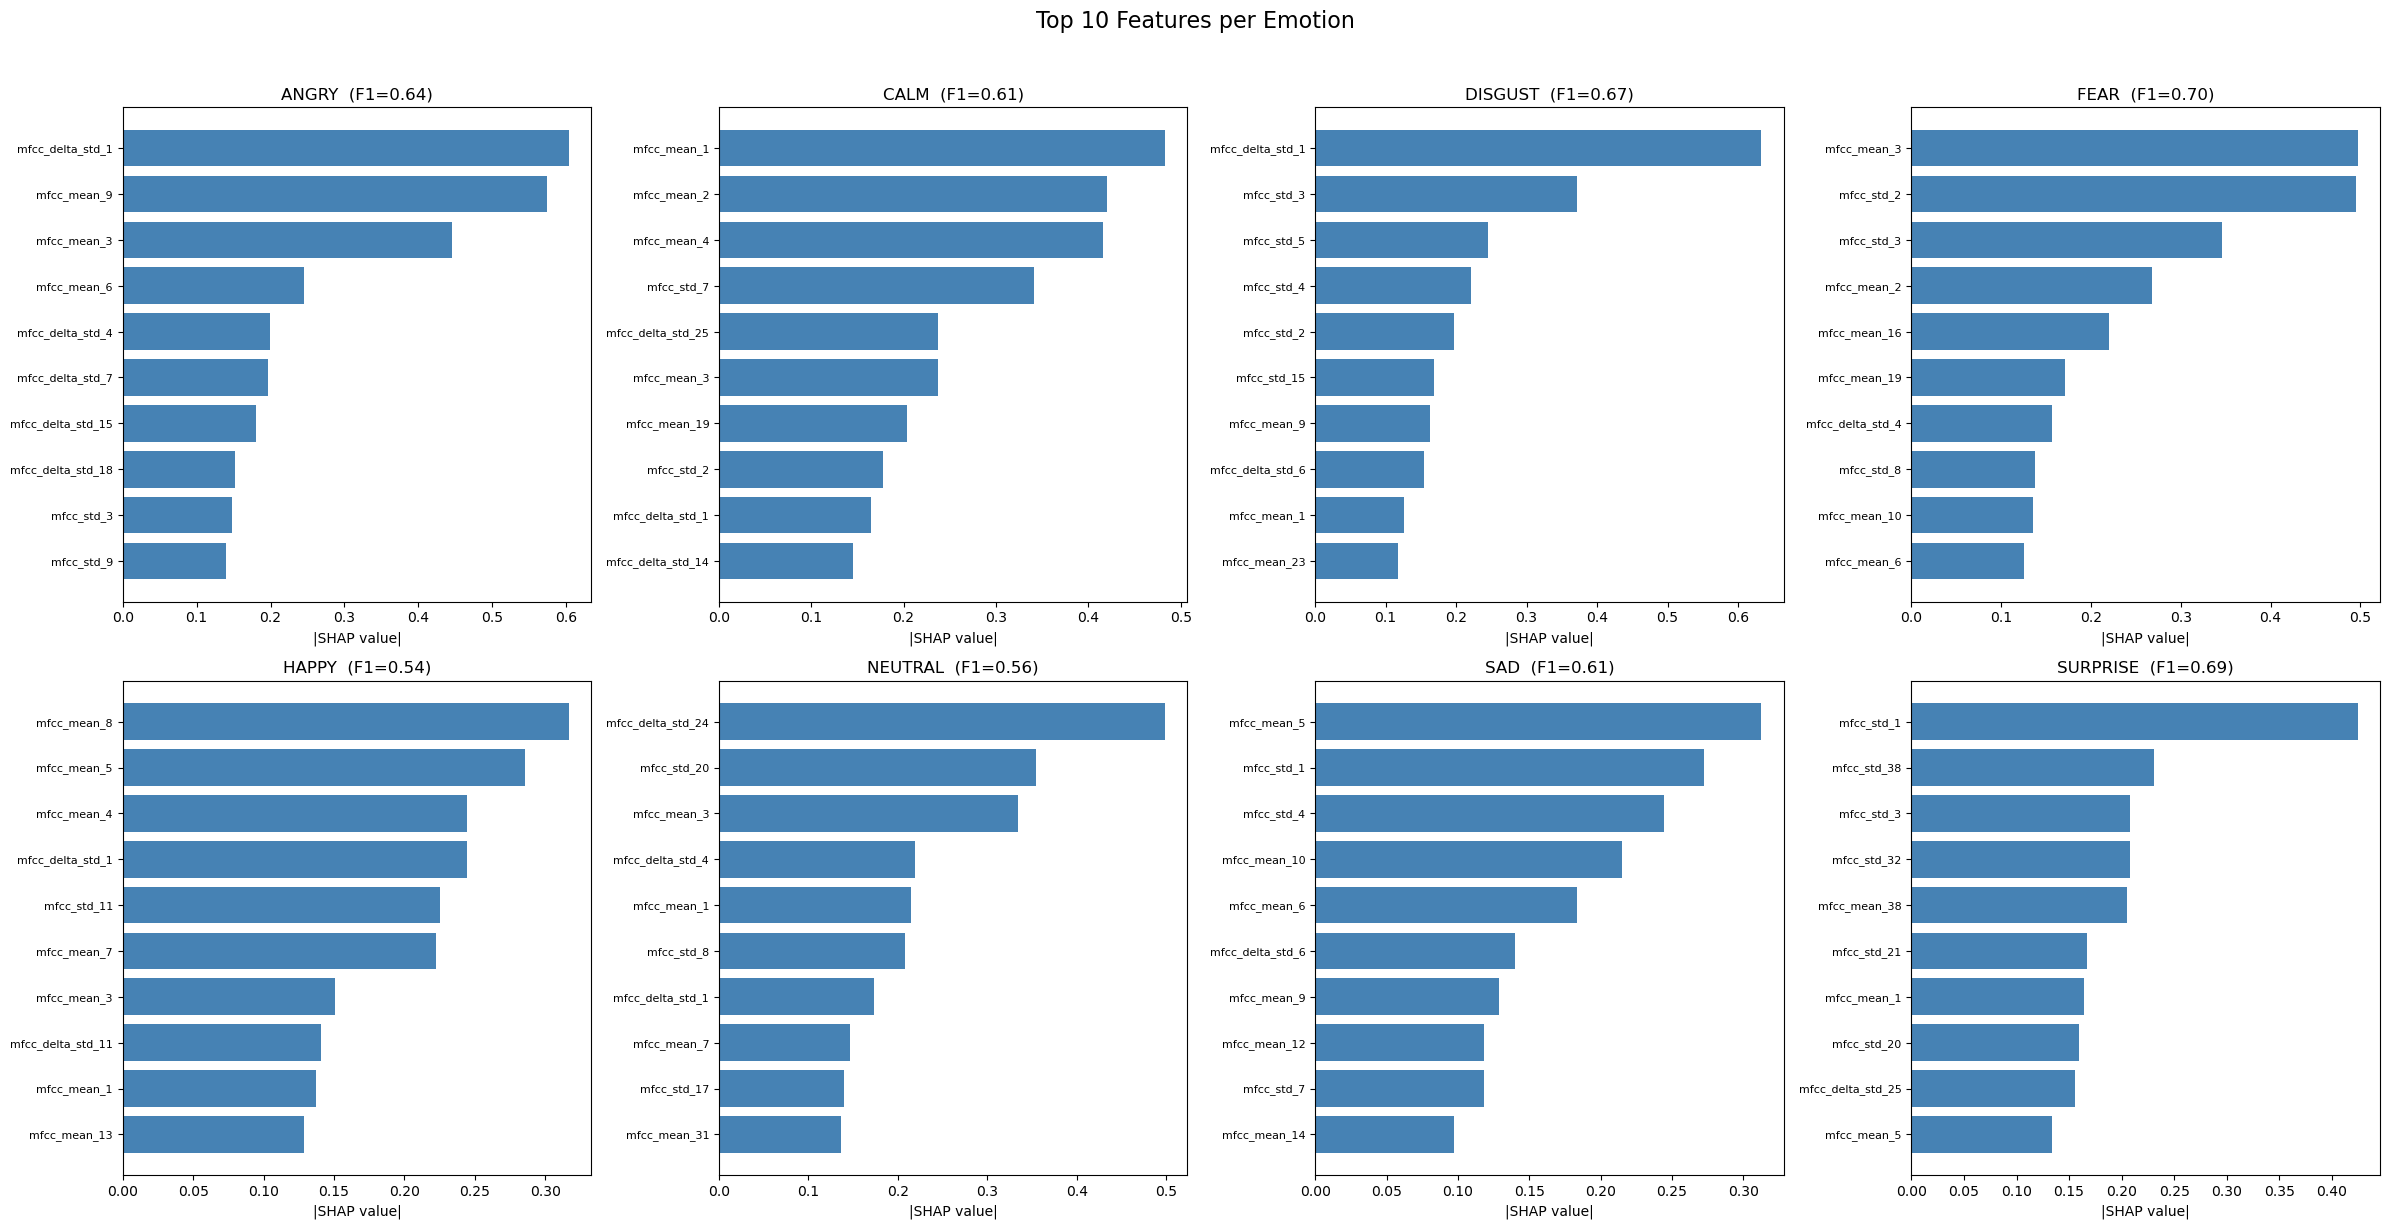

In [48]:
# Compare SHAP patterns across all 8 emotions
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for i, emotion in enumerate(classes):
    # Top 10 most important features for this emotion
    mean_shap = np.abs(shap_values[:, :, i]).mean(axis=0)
    top10_idx  = np.argsort(mean_shap)[::-1][:10]
    top10_vals = mean_shap[top10_idx]
    top10_names = [feature_names[j] for j in top10_idx]

    axes[i].barh(range(10), top10_vals[::-1], color='steelblue')
    axes[i].set_yticks(range(10))
    axes[i].set_yticklabels(top10_names[::-1], fontsize=8)
    axes[i].set_title(f"{emotion.upper()}  (F1={per_emotion_f1[i]:.2f})")
    axes[i].set_xlabel("|SHAP value|")

plt.suptitle("Top 10 Features per Emotion", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(outputs_path / "shap_per_emotion.png", dpi=150, bbox_inches='tight')
plt.show()

### 5_Local Explanation (Misclassified Sample)

Sample index:  32
True label:    happy
Predicted:     fear


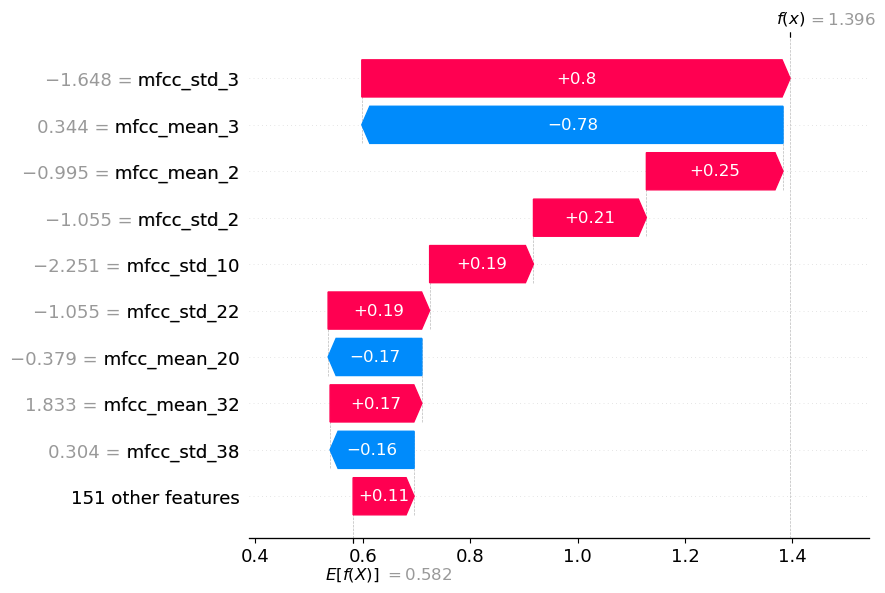

<Figure size 640x480 with 0 Axes>

In [49]:
# Find misclassified samples
y_pred_loaded = np.load(artifacts_path / "y_pred.npy")
wrong_indices = np.where(y_pred_loaded != y_test)[0]

# Focus on happy misclassified as fear (biggest confusion)
for idx in wrong_indices:
    if y_test[idx] == classes.index('happy') and \
       y_pred_loaded[idx] == classes.index('fear'):
        wrong_idx = idx
        break

print(f"Sample index:  {wrong_idx}")
print(f"True label:    {classes[y_test[wrong_idx]]}")
print(f"Predicted:     {classes[y_pred_loaded[wrong_idx]]}")

# Waterfall plot — why was this clip misclassified?
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[wrong_idx, :, y_pred_loaded[wrong_idx]],
        base_values=explainer.expected_value[y_pred_loaded[wrong_idx]],
        data=X_test_scaled[wrong_idx],
        feature_names=feature_names
    )
)
plt.savefig(outputs_path / "shap_waterfall_misclassified.png",
            dpi=150, bbox_inches='tight')
plt.show()

### 6 — SHAP Heatmap (Most Powerful Visual)

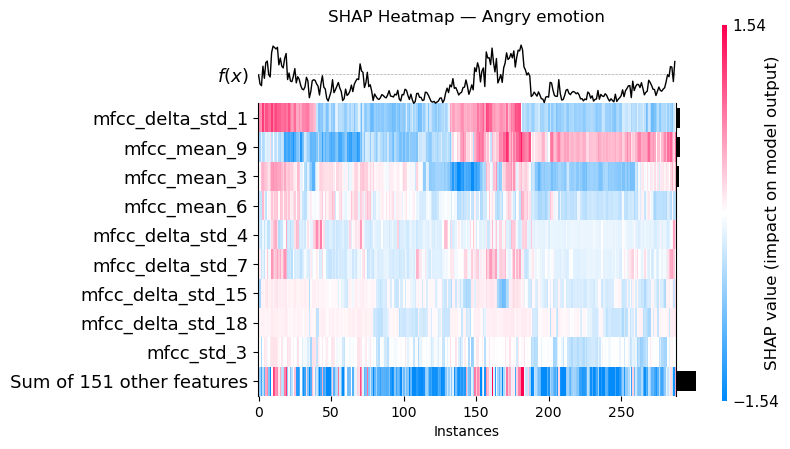

In [50]:
# Shows how features interact across all test samples
shap.plots.heatmap(
    shap.Explanation(
        values=shap_values[:, :, classes.index('angry')],
        base_values=explainer.expected_value[classes.index('angry')],
        data=X_test_scaled,
        feature_names=feature_names
    ),
    show=False
)
plt.title("SHAP Heatmap — Angry emotion")
plt.tight_layout()
plt.savefig(outputs_path / "shap_heatmap_angry.png", dpi=150, bbox_inches='tight')
plt.show()